## Task 1: Preprocess and Explore the Data

### 1. Imports and Setup

This section imports all libraries needed for data extraction, cleaning,
visualization, and statistical testing:
- `yfinance` to pull historical price data
- `pandas` / `numpy` for data manipulation
- `matplotlib` / `seaborn` for visualization
- `statsmodels` for the Augmented Dickey-Fuller stationarity test

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('deep')

### 2. Extract Historical Financial Data

We fetch daily OHLCV (Open, High, Low, Close, Volume) data for **TSLA**,
**BND**, and **SPY** from January 1, 2015 to June 30, 2026 using YFinance.

Each asset's data is downloaded separately and stored in a dictionary,
then combined into a single long-format DataFrame with a `Ticker` column
to identify which rows belong to which asset. This structure makes it
easy to group, filter, and compare assets later.

`try/except` blocks are used throughout so a failed download or
processing step for one ticker doesn't crash the entire pipeline.

In [ ]:
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-06-30'

raw_data = {}

for ticker in tickers:
    try:
        df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
        if df.empty:
            raise ValueError(f"No data returned for {ticker}")

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        raw_data[ticker] = df
        print(f"Downloaded {ticker}: {df.shape[0]} rows")
    except Exception as e:
        print(f"Error downloading {ticker}: {e}")

combined_frames = []

for ticker, df in raw_data.items():
    try:
        temp = df.copy()
        temp['Ticker'] = ticker
        temp = temp.reset_index()
        combined_frames.append(temp)
    except Exception as e:
        print(f"Error processing {ticker} into combined frame: {e}")

try:
    combined_df = pd.concat(combined_frames, ignore_index=True)
    print(combined_df.columns.tolist())
    print(combined_df.head())
except Exception as e:
    print(f"Error concatenating dataframes: {e}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Downloaded TSLA: 2888 rows
Downloaded BND: 2888 rows
Downloaded SPY: 2888 rows
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker']
Price       Date  Adj Close      Close       High        Low       Open  \
0     2015-01-02  14.620667  14.620667  14.883333  14.217333  14.858000   
1     2015-01-05  14.006000  14.006000  14.433333  13.810667  14.303333   
2     2015-01-06  14.085333  14.085333  14.280000  13.614000  14.004000   
3     2015-01-07  14.063333  14.063333  14.318667  13.985333  14.223333   
4     2015-01-08  14.041333  14.041333  14.253333  14.000667  14.187333   

Price    Volume Ticker  
0      71466000   TSLA  
1      80527500   TSLA  
2      93928500   TSLA  
3      44526000   TSLA  
4      51637500   TSLA  


### 3. Data Cleaning and Understanding: Statistics & Data Types

Before modeling, we inspect the dataset's shape and distribution using
`.describe()` and check that each column has the correct data type.

- `Date` is converted to a proper `datetime` type (needed for time series
  operations and plotting)
- `Ticker` is converted to a `category` type for memory efficiency and
  cleaner grouping operations

In [19]:
try:
    print("Data types:\n", combined_df.dtypes)
    print("\nBasic statistics:\n", combined_df.describe())
except Exception as e:
    print(f"Error inspecting combined_df: {e}")

try:
    combined_df['Date'] = pd.to_datetime(combined_df['Date'])
    combined_df['Ticker'] = combined_df['Ticker'].astype('category')
except Exception as e:
    print(f"Error fixing dtypes: {e}")

Data types:
 Price
Date         datetime64[s]
Adj Close          float64
Close              float64
High               float64
Low                float64
Open               float64
Volume               int64
Ticker                 str
dtype: object

Basic statistics:
 Price                 Date    Adj Close        Close         High  \
count                 8664  8664.000000  8664.000000  8664.000000   
mean   2020-09-27 06:13:27   188.927503   201.106120   202.866633   
min    2015-01-02 00:00:00     9.578000     9.578000    10.331333   
25%    2017-11-12 06:00:00    62.672689    74.070000    74.207499   
50%    2020-09-26 12:00:00   133.437668   133.437668   136.053329   
75%    2023-08-10 06:00:00   279.182503   294.117508   298.355003   
max    2026-06-29 00:00:00   757.618225   759.570007   760.400024   
std                    NaN   169.807462   171.936619   173.233832   

Price          Low         Open        Volume  
count  8664.000000  8664.000000  8.664000e+03  
mean    199.1

### 4. Handling Missing Values

We check for missing values per ticker, since gaps can occur from
holidays, data provider issues, or mismatched trading calendars across
assets.

Missing values in `Close` and `Adj Close` are filled using **linear
interpolation** within each ticker group (rather than dropping rows
outright), since financial time series are continuous and interpolation
preserves trend continuity better than forward/backward fill for small
gaps. Any remaining unfillable rows are dropped.

In [20]:
try:
    missing_summary = combined_df.groupby('Ticker').apply(lambda x: x.isnull().sum())
    print("Missing values per ticker:\n", missing_summary)
except Exception as e:
    print(f"Error checking missing values: {e}")

try:
    combined_df = combined_df.sort_values(['Ticker', 'Date'])
    combined_df['Adj Close'] = combined_df.groupby('Ticker')['Adj Close'].transform(
        lambda x: x.interpolate(method='linear')
    )
    combined_df['Close'] = combined_df.groupby('Ticker')['Close'].transform(
        lambda x: x.interpolate(method='linear')
    )
    combined_df = combined_df.dropna(subset=['Adj Close', 'Close'])
    print("Remaining missing values:\n", combined_df.isnull().sum())
except Exception as e:
    print(f"Error handling missing values: {e}")

Missing values per ticker:
 Price   Date  Adj Close  Close  High  Low  Open  Volume
Ticker                                                 
BND        0          0      0     0    0     0       0
SPY        0          0      0     0    0     0       0
TSLA       0          0      0     0    0     0       0
Remaining missing values:
 Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Ticker       0
dtype: int64


### 5. Save Cleaned Dataset

The cleaned, combined dataset is saved to `data/processed/` as a CSV.
This gives us a reusable checkpoint so later notebooks (modeling,
forecasting, portfolio optimization) don't need to re-fetch or
re-clean the raw data.

In [21]:
try:
    combined_df.to_csv('../data/processed/combined_assets.csv', index=False)
    print("Saved processed data.")
except Exception as e:
    print(f"Error saving processed data: {e}")

Saved processed data.


### 6. Exploratory Data Analysis: Closing Price Over Time

Plotting adjusted closing price over time for all three assets lets us
visually identify long-term trends, growth phases, and major market
events (e.g., the 2020 COVID crash, 2021-2022 volatility). TSLA is
expected to show much higher growth and volatility than BND or SPY.

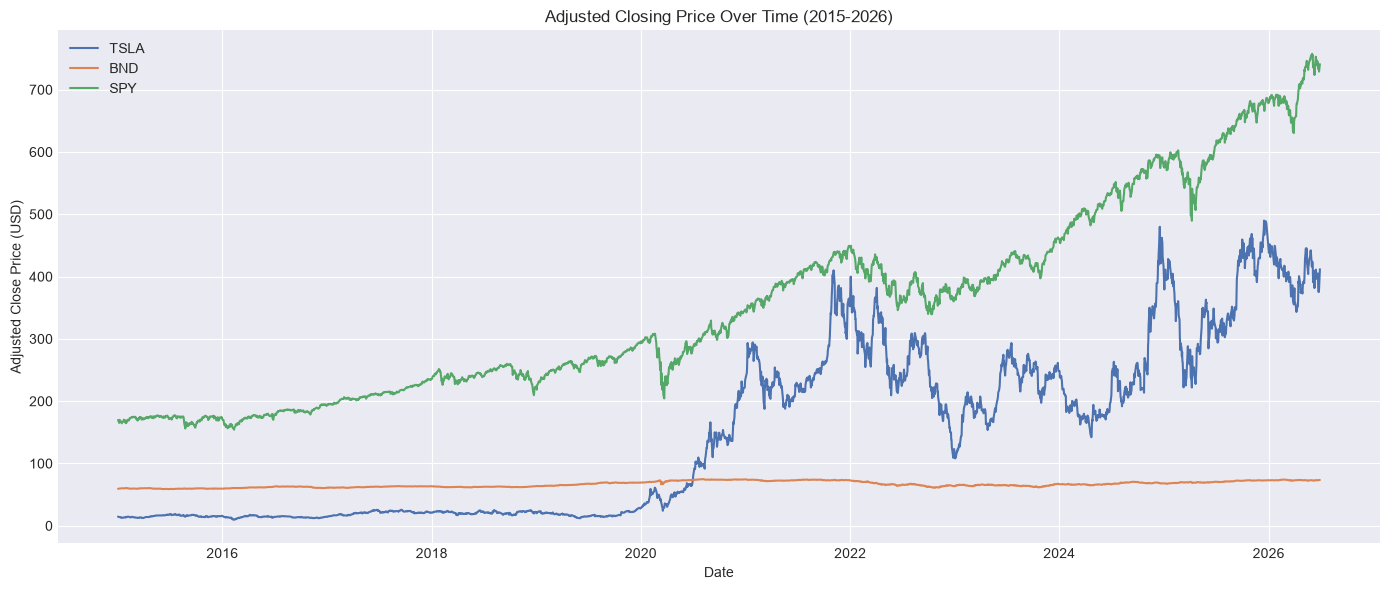

In [22]:
try:
    fig, ax = plt.subplots(figsize=(14, 6))
    for ticker in tickers:
        subset = combined_df[combined_df['Ticker'] == ticker]
        ax.plot(subset['Date'], subset['Adj Close'], label=ticker)
    ax.set_title('Adjusted Closing Price Over Time (2015-2026)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Adjusted Close Price (USD)')
    ax.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting closing prices: {e}")

### 7. Daily Percentage Change (Volatility)

We calculate daily returns as the percentage change in adjusted close
price day-over-day. This transforms the price series into a returns
series, which fluctuates around zero and makes volatility easier to
compare across assets with very different price scales (e.g., TSLA vs.
BND).

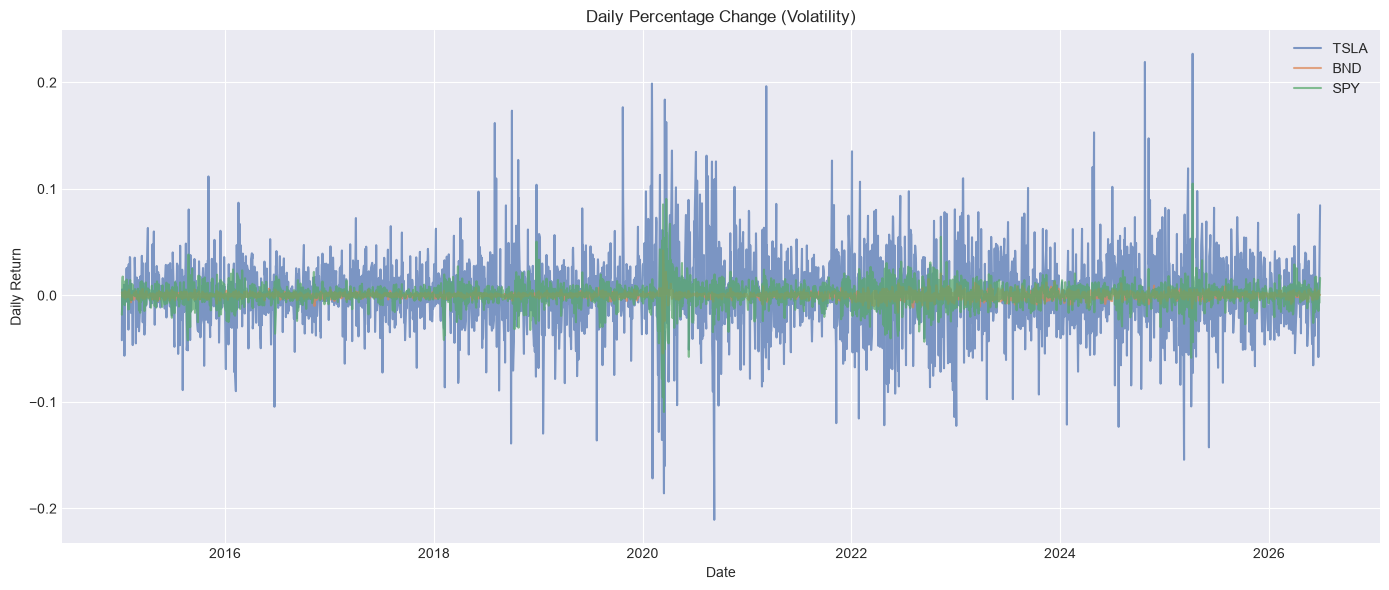

In [24]:
try:
    combined_df['Daily_Return'] = combined_df.groupby('Ticker')['Adj Close'].pct_change()

    fig, ax = plt.subplots(figsize=(14, 6))
    for ticker in tickers:
        subset = combined_df[combined_df['Ticker'] == ticker]
        ax.plot(subset['Date'], subset['Daily_Return'], label=ticker, alpha=0.7)
    ax.set_title('Daily Percentage Change (Volatility)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Daily Return')
    ax.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error calculating/plotting daily returns: {e}")

### 8. Rolling Mean and Standard Deviation

Using a 30-day rolling window, we calculate:
- **Rolling mean**: smooths out short-term noise to reveal the
  underlying trend
- **Rolling standard deviation**: measures how volatility itself
  changes over time (volatility clustering)

The shaded band around the rolling mean visualizes periods of higher
vs. lower risk for each asset.

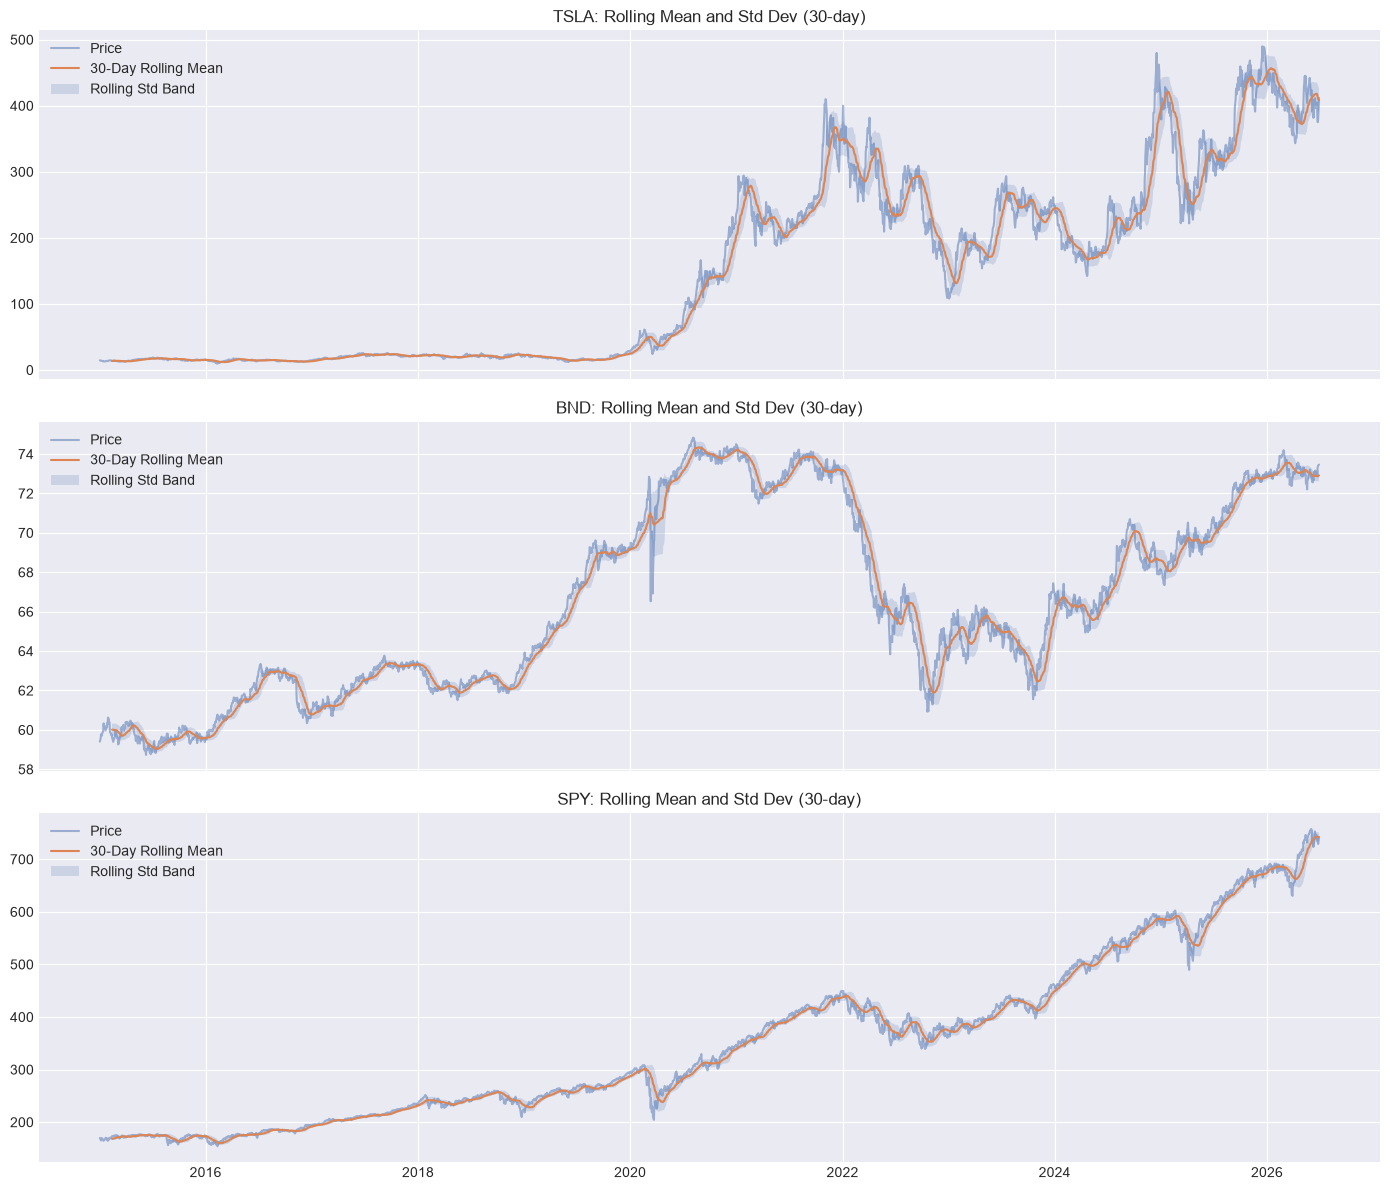

In [25]:
try:
    window = 30
    fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 12), sharex=True)

    for i, ticker in enumerate(tickers):
        subset = combined_df[combined_df['Ticker'] == ticker].copy()
        subset['Rolling_Mean'] = subset['Adj Close'].rolling(window=window).mean()
        subset['Rolling_Std'] = subset['Adj Close'].rolling(window=window).std()

        axes[i].plot(subset['Date'], subset['Adj Close'], label='Price', alpha=0.5)
        axes[i].plot(subset['Date'], subset['Rolling_Mean'], label=f'{window}-Day Rolling Mean')
        axes[i].fill_between(
            subset['Date'],
            subset['Rolling_Mean'] - subset['Rolling_Std'],
            subset['Rolling_Mean'] + subset['Rolling_Std'],
            alpha=0.2, label='Rolling Std Band'
        )
        axes[i].set_title(f'{ticker}: Rolling Mean and Std Dev ({window}-day)')
        axes[i].legend()

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error computing rolling statistics: {e}")

### 9. Outlier Detection

Days where the daily return deviates more than 3 standard deviations
from the mean are flagged as outliers. These typically correspond to
earnings announcements, macroeconomic shocks, or company-specific news
events (especially relevant for TSLA, which has a history of large
single-day moves).

In [26]:
try:
    outliers_summary = {}
    for ticker in tickers:
        subset = combined_df[combined_df['Ticker'] == ticker].copy()
        mean_ret = subset['Daily_Return'].mean()
        std_ret = subset['Daily_Return'].std()
        threshold = 3
        subset['Is_Outlier'] = np.abs(subset['Daily_Return'] - mean_ret) > (threshold * std_ret)
        outliers = subset[subset['Is_Outlier']]
        outliers_summary[ticker] = outliers[['Date', 'Daily_Return']]
        print(f"\n{ticker}: {len(outliers)} outlier days found")
        print(outliers[['Date', 'Daily_Return']].sort_values('Daily_Return').head())
except Exception as e:
    print(f"Error detecting outliers: {e}")


TSLA: 46 outlier days found
Price       Date  Daily_Return
1430  2020-09-08     -0.210628
1308  2020-03-16     -0.185778
1281  2020-02-05     -0.171758
1310  2020-03-18     -0.160344
2560  2025-03-10     -0.154262

BND: 33 outlier days found
Price       Date  Daily_Return
4194  2020-03-12     -0.054385
4198  2020-03-18     -0.024141
4197  2020-03-17     -0.020685
4193  2020-03-11     -0.018940
4762  2022-06-13     -0.016153

SPY: 39 outlier days found
Price       Date  Daily_Return
7084  2020-03-16     -0.109424
7082  2020-03-12     -0.095677
7079  2020-03-09     -0.078094
8355  2025-04-04     -0.058543
7145  2020-06-11     -0.057649


### 10. Days with Unusually High or Low Returns

We extract the top 5 highest and lowest single-day returns for each
asset. Cross-referencing these dates with known news events can help
explain the drivers behind extreme volatility and inform risk
management assumptions later in the project.

In [27]:
try:
    for ticker in tickers:
        subset = combined_df[combined_df['Ticker'] == ticker]
        top_gains = subset.nlargest(5, 'Daily_Return')[['Date', 'Daily_Return']]
        top_losses = subset.nsmallest(5, 'Daily_Return')[['Date', 'Daily_Return']]
        print(f"\n{ticker} - Top 5 Gains:\n{top_gains}")
        print(f"\n{ticker} - Top 5 Losses:\n{top_losses}")
except Exception as e:
    print(f"Error identifying extreme return days: {e}")


TSLA - Top 5 Gains:
Price       Date  Daily_Return
2582  2025-04-09      0.226900
2469  2024-10-24      0.219190
1279  2020-02-03      0.198949
1555  2021-03-09      0.196412
1311  2020-03-19      0.183877

TSLA - Top 5 Losses:
Price       Date  Daily_Return
1430  2020-09-08     -0.210628
1308  2020-03-16     -0.185778
1281  2020-02-05     -0.171758
1310  2020-03-18     -0.160344
2560  2025-03-10     -0.154262

BND - Top 5 Gains:
Price       Date  Daily_Return
4195  2020-03-13      0.042201
4201  2020-03-23      0.022149
4867  2022-11-10      0.020702
4200  2020-03-20      0.016956
4836  2022-09-28      0.015544

BND - Top 5 Losses:
Price       Date  Daily_Return
4194  2020-03-12     -0.054385
4198  2020-03-18     -0.024141
4197  2020-03-17     -0.020685
4193  2020-03-11     -0.018940
4762  2022-06-13     -0.016153

SPY - Top 5 Gains:
Price       Date  Daily_Return
8358  2025-04-09      0.105019
7090  2020-03-24      0.090603
7083  2020-03-13      0.085486
7099  2020-04-06      0.0671

### 11. Stationarity Testing: Augmented Dickey-Fuller (ADF) Test

The ADF test checks whether a time series is stationary (constant mean
and variance over time) — a key assumption for ARIMA modeling.

- **Null hypothesis**: the series has a unit root (non-stationary)
- **p-value < 0.05**: reject the null → series is stationary
- **p-value ≥ 0.05**: fail to reject → series is non-stationary

We run this test on both raw closing prices and daily returns for each
asset.

**Interpretation:** Closing prices are typically non-stationary,
confirming that differencing (the `d` parameter in ARIMA) is required.
Daily returns are typically already stationary, since they are
effectively the first-differenced price series.

In [ ]:
try:
    adf_results = {}
    for ticker in tickers:
        subset = combined_df[combined_df['Ticker'] == ticker]

        price_series = subset['Adj Close'].dropna()
        price_adf = adfuller(price_series)

        return_series = subset['Daily_Return'].dropna()
        return_adf = adfuller(return_series)

        adf_results[ticker] = {
            'price_pvalue': price_adf[1],
            'price_stationary': price_adf[1] < 0.05,
            'return_pvalue': return_adf[1],
            'return_stationary': return_adf[1] < 0.05
        }

        print(f"\n{ticker}")
        print(f"  Price ADF p-value: {price_adf[1]:.4f} -> {'Stationary' if price_adf[1] < 0.05 else 'Non-Stationary'}")
        print(f"  Return ADF p-value: {return_adf[1]:.4f} -> {'Stationary' if return_adf[1] < 0.05 else 'Non-Stationary'}")
except Exception as e:
    print(f"Error running ADF test: {e}")